# Part 1 — Filtering, Denoising & Gradients (EC ENGR 149, HW1)

# Homework 1

## Motivation:
This problem set covers the basic concepts of image processing, and connects them to signal processing concepts covered in class.

The problem set consists of -     
a) analytical questions to solidify the concepts covered in the class.    
b) coding questions to provide a basic exposure in image processing using python.

You will explore various applications of convolution such as image filtering, blurring denoising, visualizing edges and blurring while preserving edges. These are fundamental concepts with applications in many computer vision tasks.

These are some of the libraries/modules you will require for this homework. Make sure you have them installed. You can use anaconda (https://docs.anaconda.com/anaconda/install/mac-os/) and Jupyter notebook/lab (https://jupyter.org/install).

In [ ]:
#%load_ext autoreload
#%autoreload 2
%matplotlib inline
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import copy
import os

path = 'Data'

In [ ]:
!pip install gdown==4.6.3

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.1
    Uninstalling gdown-5.2.1:
      Successfully uninstalled gdown-5.2.1


In [ ]:
!gdown https://drive.google.com/uc?id=1Me8RzQ53q1qqf9JOwCaXI9mb7Rqx6Zii
!unzip homework1_data.zip

Downloading...
From: https://drive.google.com/uc?id=1Me8RzQ53q1qqf9JOwCaXI9mb7Rqx6Zii
To: /content/homework1_data.zip
100% 73.5k/73.5k [00:00<00:00, 67.9MB/s]
Archive:  homework1_data.zip
   creating: Data/Solutions/
  inflating: Data/Singles/noisy_house.png  
  inflating: Data/Singles/house.png  


These are some functions which will be useful throught the homework to (1) display a single grayscale image, (2) display multiple images using subplots, (3) computing the relative absolute distance between two images.

In [ ]:
def display_gray(x: np.array, normalized:bool = False):
    if not normalized:
        plt.imshow(x,cmap='gray',vmin=0,vmax=1)
    else:
        plt.imshow(x/x.max(),cmap='gray',vmin=0,vmax=1)

In [ ]:
def display_axis(ax: plt.axis, x: np.array, title: str, normalized:bool = False):
    if not normalized:
        ax.imshow(x,cmap='gray',vmin=0,vmax=1)
    else:
        ax.imshow(x/x.max(),cmap='gray',vmin=0,vmax=1)
    ax.set_title(title,size=18)

In [ ]:
def rel_l1_dist(x1: np.array, x2: np.array):
    return np.abs(x1-x2).sum()/np.abs(x1).sum()

Load the house image from `Data/Singles` using Pillow (PIL) into a 2D-array `img_data`. Normalize the image by dividing it with 255.

In [ ]:
image = Image.open(os.path.join(path,'Singles/house.png'))
img_data = np.asarray(image)/255

Display the image using `display_gray` defined above.

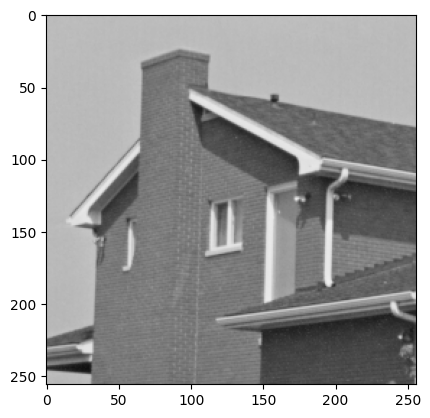

In [ ]:
display_gray(img_data)

Print the size of the image

In [ ]:
print(f'Image size: {img_data.shape[0]}x{img_data.shape[1]}')

Image size: 256x256


# Question 2

### 2D-Convolution

Here you will be implementing the 2D convolution operation using `for` loops. You will be completing the function `conv2D(image, kernel)`.  

For this part assume that you are given a grayscale `image` (house) and you want to convolve it with a `kernel` (for example, identity, average or gaussian) such that the output image has the same size as the input `image` (you will need to zero pad the `image` appropriately on all the sides before performing the convolution). The function should return convolution of `image` and `kernel`.

*Note:* The origin of the kernel should be the center pixel of the filter, while the origin for the image should be the top left pixel of the image before zero padding. For this homework we will assume that all the filters are `square` and `odd-sized`.

### **Answer 2:**

Copy paste your solution in the cell below on overleaf for Question 2.

In [ ]:
# Write your answer in this cell. Then copy paste the code into the overleaf file corresponding to Question 2.
def conv2D(image: np.array, kernel: np.array = None):
    H, W = image.shape
    k = kernel.shape[0]
    pad = k // 2

    kernel = np.flip(kernel, (0, 1))

    padded = np.zeros((H + 2 * pad, W + 2 * pad), dtype=image.dtype)
    padded[pad:pad + H, pad:pad + W] = image

    output = np.zeros_like(image, dtype=np.float64)

    for i in range(H):
        for j in range(W):
            region = padded[i:i + k, j:j + k]
            output[i, j] = np.sum(region * kernel)

    return output

One easy way to verify the correctness of the implementation is to make sure that convolving with an identity filter returns the same image. Make sure that you dont get an assertion error.

In [ ]:
def identity_filter(size: int):
    assert size%2 == 1
    iden_filt = np.zeros((size,size))
    iden_filt[size//2,size//2]=1
    return iden_filt

In [ ]:
iden_filt = identity_filter(5)
conv_iden = conv2D(img_data, iden_filt)
assert np.abs(img_data-conv_iden).sum() == 0.0

# Question 3

### Application of Convolution

In this question you will be using convolution to perform image blurring and denoising.

Average/Box Filter: This is the standard box filter which computes the mean of all the pixels.

In [ ]:
def average_filter(size: int):
    assert size%2 == 1
    return 1.0 * np.ones((size,size))/(size**2)

## (1) Gaussian Filter



The formula for a 2-D isotropic gaussian distribution with variance $\sigma^2$ and mean $= [\mu_x, \mu_y]$ is given by

$p(x,y) = \dfrac{1}{2\pi\sigma^2}\exp{\big(-\dfrac{(x-\mu_x)^2+(y-\mu_y)^2}{2\sigma^2}\big)}$

Using the equation above, complete the function `gaussian_filter(size, sigma)` which given a filter size and standard deviation, returns a centered gaussian filter. Unlike the usual 2-D gaussian which is defined on a continuous space, for the gaussian filter you will assume that $x,y,\mu_x,\mu_y$ are discrete integers.

*Note:* Dont forget to normalize the filter to make sure that it sums to 1. Since the filter size is odd, assume the center pixel to the origin and the mean of the gaussian.

### **Answer 3.1:**
Copy paste your solution in the cell below on overleaf for Question 3.1.

In [ ]:
import numpy as np
# Write your answer in this cell.
def gaussian_filter(size: int, sigma: float):
  kernel = np.zeros((size, size))
  center = size // 2
  for i in range(size):
    for j in range(size):
      # compute x, y
      x = i - center
      y = j -center
      # apply formula
      p = 1/(2*np.pi*sigma*sigma)*np.exp(-(((x)**2+(y)**2)/(2*sigma*sigma)))
      # store value
      kernel[i, j] = p

  kernel = kernel / np.sum(kernel)
  return kernel

## (2)

Execute the cell below which will display the images with increasing variance. You should observe that the radius of the white circle in increases with $\sigma$. It will also save an image `question_3_b.pdf`, just put this image on overleaf for question 3.2.

### **Answer 3.2:**

# Execute the cell below and copy the saved image on overleaf for Question 3.2.

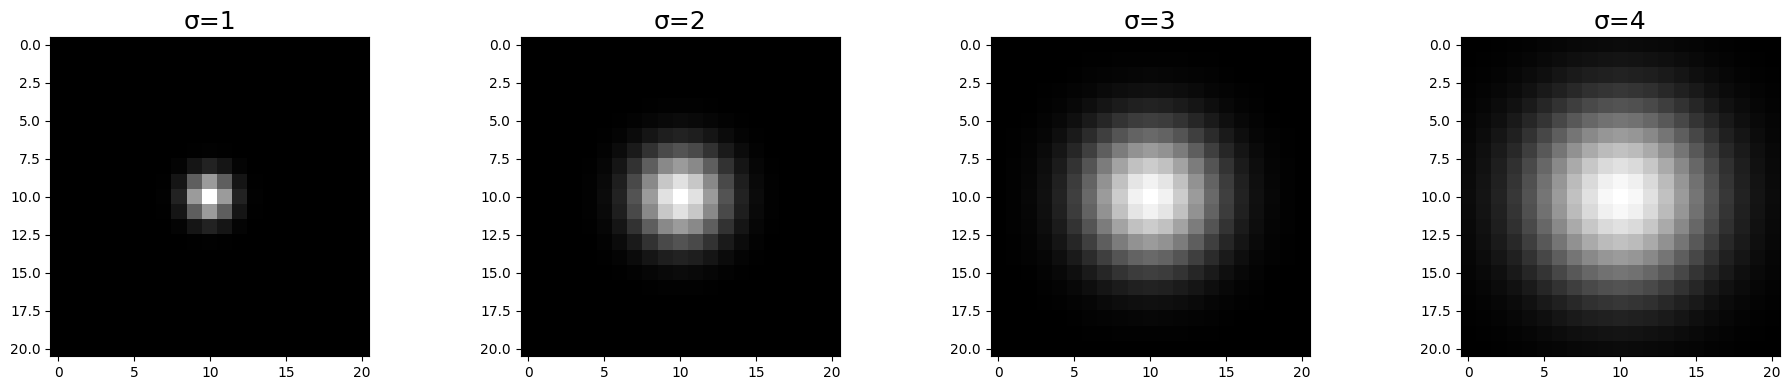

In [ ]:
fig, ax = plt.subplots(1,4,figsize=(1 + 4*4.5,4))
for i in range(1,5):
    gauss_filt = gaussian_filter(21,i)
    display_axis(ax[i-1],gauss_filt,f'\u03C3={i}', normalized=True)
fig.tight_layout()
fig.savefig('Data/Solutions/question_3_2.pdf', format='pdf', bbox_inches='tight')

### Image Blurring

In this sub-part you will see that the average and gaussian filter can be used for image blurring. If your implementation of Conv2D and gaussian filter is correct then you should observe that increasing the filter size for the average filter and the filter size/variance for the gaussian filter will increase the blurring. So the images on the right will be more blurred.

#### Average Filter

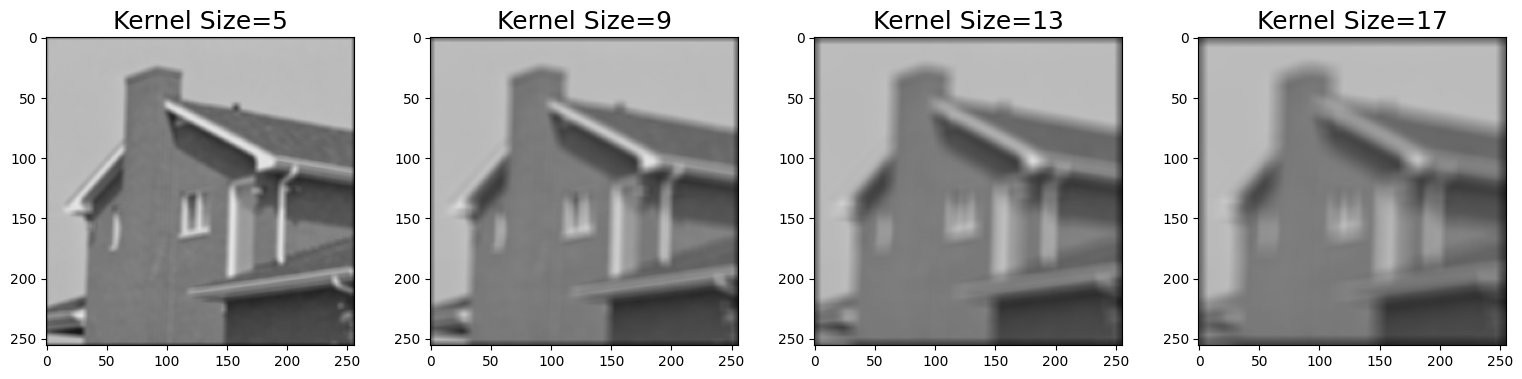

In [ ]:
fig, ax = plt.subplots(1,4,figsize=(1 + 4*4.5,4))
for i in range(1,5):
    size = 4*i+1
    avg_filt = average_filter(size)
    conv_avg = conv2D(img_data, avg_filt)
    display_axis(ax[i-1],conv_avg,f'Kernel Size={size}')

## (3)
#### Gaussian Filter

### **Answer 3.3:**

Execute the cell below and copy the saved image on overleaf for Question 3.3.

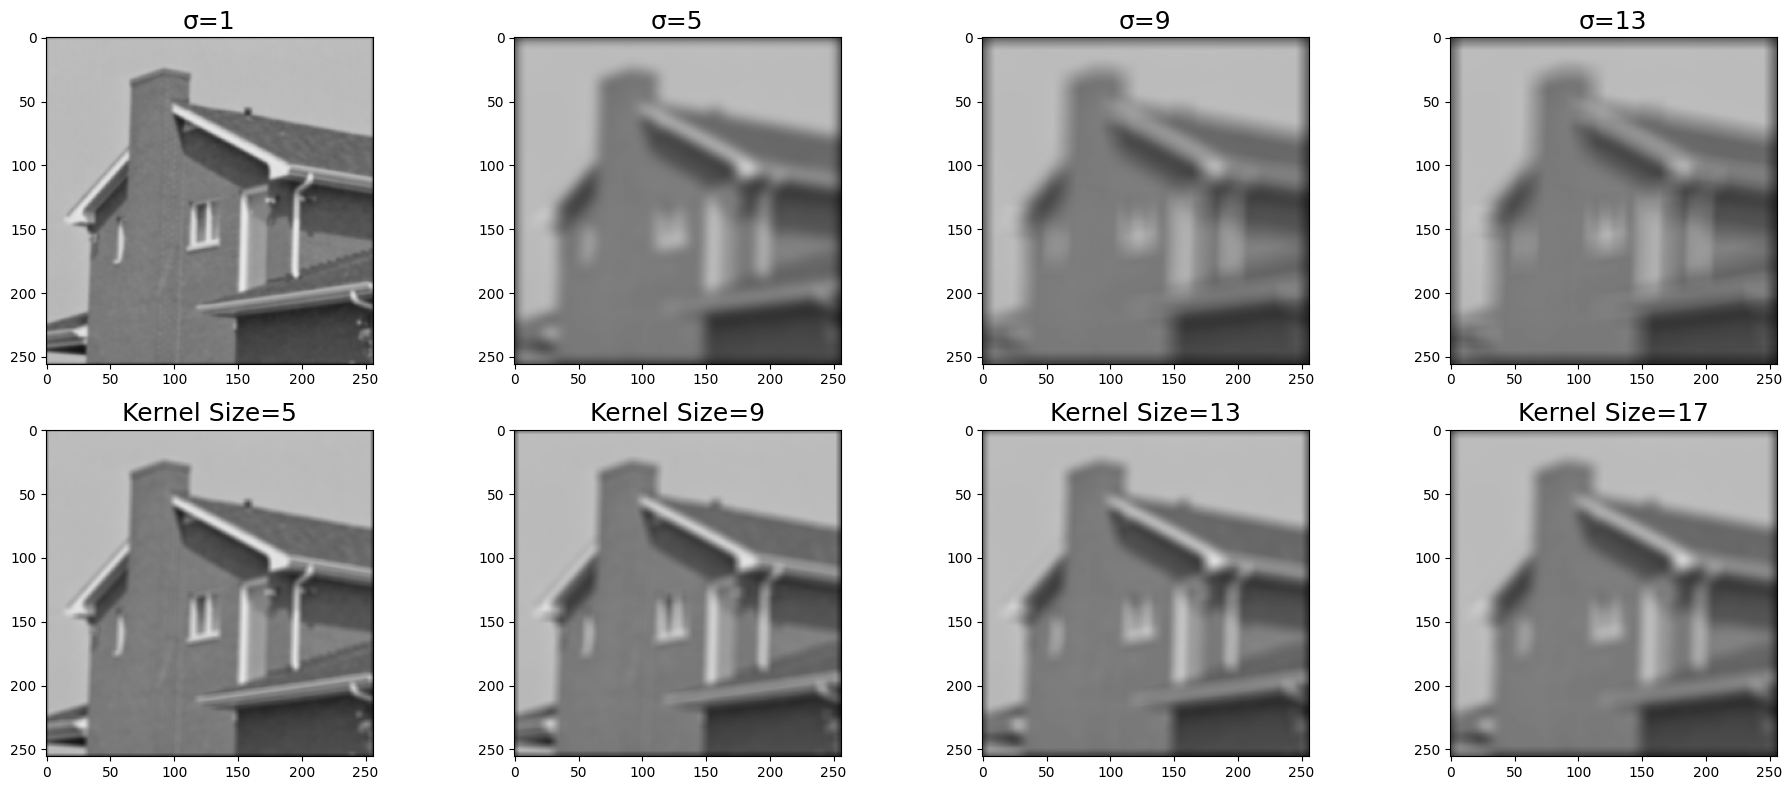

In [ ]:
fig, ax = plt.subplots(2,4,figsize=(1 + 4*4.5,2*4))
for i in range(1,5):
    sigma = 4*(i-1)+1
    s = 4*i + 1
    gauss_filt = gaussian_filter(21,sigma)
    conv_gauss = conv2D(img_data, gauss_filt)
    display_axis(ax[0,i-1],conv_gauss,f'\u03C3={sigma}')
    gauss_filt = gaussian_filter(s,5)
    conv_gauss = conv2D(img_data, gauss_filt)
    display_axis(ax[1,i-1],conv_gauss,f'Kernel Size={s}')
fig.tight_layout()
fig.savefig('Data/Solutions/question_3_3.pdf', format='pdf', bbox_inches='tight')

## Image Denoising

In this question you will use `conv2D` to perform image denoising. You will use three types of filtering for denoising: (i) average, (ii) gaussian and (iii) median. Average and Gaussian filtering can easily be performed using the current implementation of the `conv2D` function. However, the median filter cannot be characterized using a known filter just like average, gaussian. You will write a function for performing median filtering.

You will perform all the three types of filtering and report best filtering method by looking at the images and also using numerical quantification (you may find the `rel_abs_dist` function useful for this part.

Display the noisy image

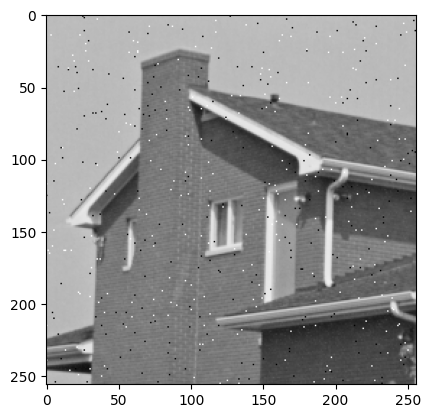

In [ ]:
noisy_img_data = np.asarray(Image.open('Data/Singles/noisy_house.png'))
noisy_img_data = noisy_img_data/255
display_gray(noisy_img_data)

## (4)
### Median filtering

Complete the function `median_filtering(image, kernel_size)` which takes the `image` as input along with the `kernel_size` and the returns the median filtered output which has the same size as the input image (you need to perform zero padding).

### **Answer 3.5:**
Copy paste your solution in the cell below on overleaf for Question 3.5.

In [ ]:
# Write your answer in this cell. Then copy paste the code into the overleaf file corresponding to Question 3 (d).

def median_filtering(image: np.array, kernel_size: int = None):
  H, W = image.shape
  k = kernel_size
  pad = k // 2

  padded = np.zeros((H + 2*pad, W + 2*pad))
  padded[pad:pad+H, pad:pad+W] = image
  output = np.zeros_like(image)

  for i in range(H):
    for j in range(W):
      region = padded[i:i+k, j:j+k]
      output[i, j] = np.median(region)

  return output


Perform the 3 types of filtering.

In [ ]:
avg_filt = average_filter(7)
gauss_filt = gaussian_filter(7,3)
avg_filt_noisy_img = conv2D(noisy_img_data, avg_filt)
gauss_filt_noisy_img = conv2D(noisy_img_data, gauss_filt)
median_filt_noisy_img = median_filtering(noisy_img_data,7)

Display all the images.

### **Answer 3.6:**

Execute the cell below and copy the saved image on overleaf for Question 3.5.

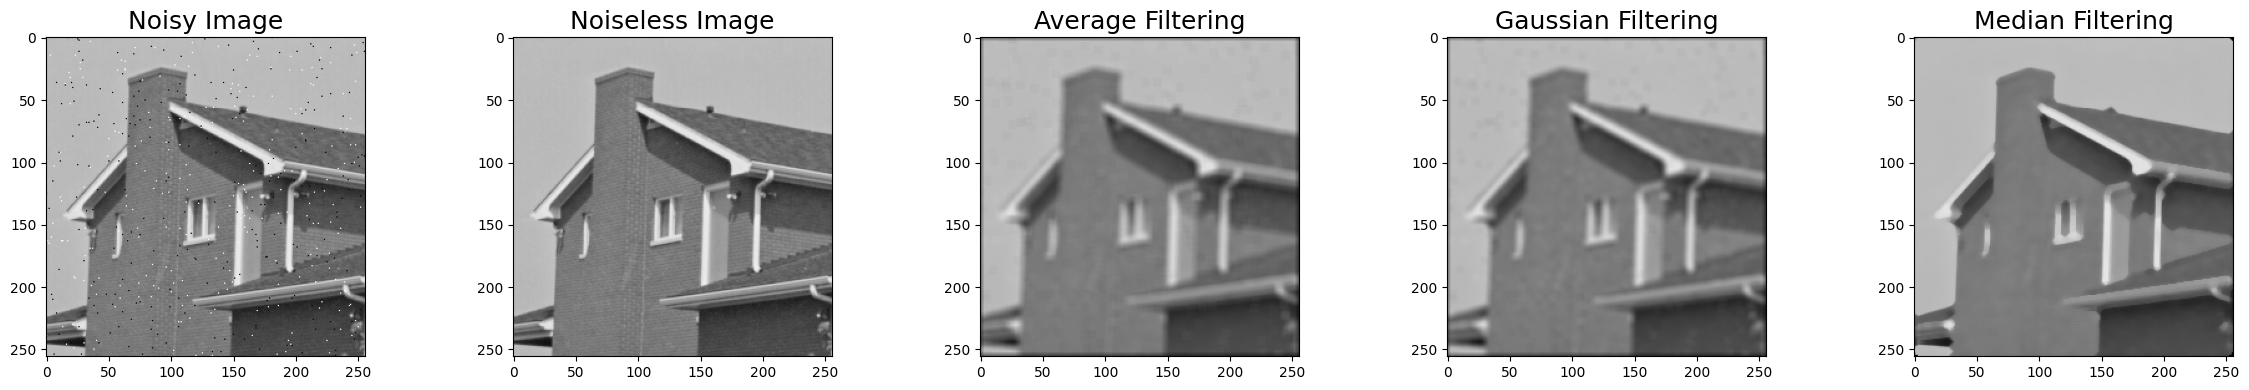

In [ ]:
fig, ax = plt.subplots(1,5,figsize=(1 + 5*4.5,4))
display_axis(ax[0],noisy_img_data, 'Noisy Image')
display_axis(ax[1],img_data, 'Noiseless Image')
display_axis(ax[2],avg_filt_noisy_img,'Average Filtering')
display_axis(ax[3],gauss_filt_noisy_img,'Gaussian Filtering')
display_axis(ax[4],median_filt_noisy_img,'Median Filtering')
fig.tight_layout()
fig.savefig('Data/Solutions/question_3_5.pdf', format='pdf', bbox_inches='tight')

Relative absolute distance

In [ ]:
print(f'Average Filtering: {rel_l1_dist(img_data, avg_filt_noisy_img)}')
print(f'Gaussian Filtering: {rel_l1_dist(img_data, gauss_filt_noisy_img)}')
print(f'Median Filtering: {rel_l1_dist(img_data, median_filt_noisy_img)}')

Average Filtering: 0.06525493187234264
Gaussian Filtering: 0.05995105367092967
Median Filtering: 0.03332913485508449


## Question 4

## Gradients

In this question you will be using convolution, `conv2D` to compute the gradients in the image. Gradients are useful in obtaining the edges in an image. Multiple edge level features can be combined to obtain higher level features which are useful in image classification.

Design a filter to compute the gradient along the horizontal and vertical direction. After convolving with a filter which computes the gradient along the horizontal direction you should observe that all the vertical edges in the filtered image and vice-versa.

*Hint:* See Prewitt filter

## (1)

Design a filter `gradient_x` for computing the horizontal gradient (along the x direction) using `conv2D`.

### **Answer 4.1:**
Copy paste your solution in the cell below on overleaf for Question 4.1.

In [ ]:
# Write your code in this cell.
gradient_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

## (2)

Design a filter `gradient_y` for computing the vertical gradient (along the y direction) using `conv2D`.

### **Answer 4.2:**
Copy paste your solution in the cell below on overleaf for Question 4.2.

In [ ]:
# Write your code in this cell.
gradient_y = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 0, 1]
])



```
# This is formatted as code
```

Display the absolute gradient along the horizontal, vertical directions and their sum. You should observe that the gradient in the horizontal (x-direction) is unable to capture the horizontal parts of the rooftops, while the vertical gradient is unable to features like the edges of chimney.

### **Answer 4.3:**

Execute the cell below and copy the saved image on overleaf for Question 4.3.

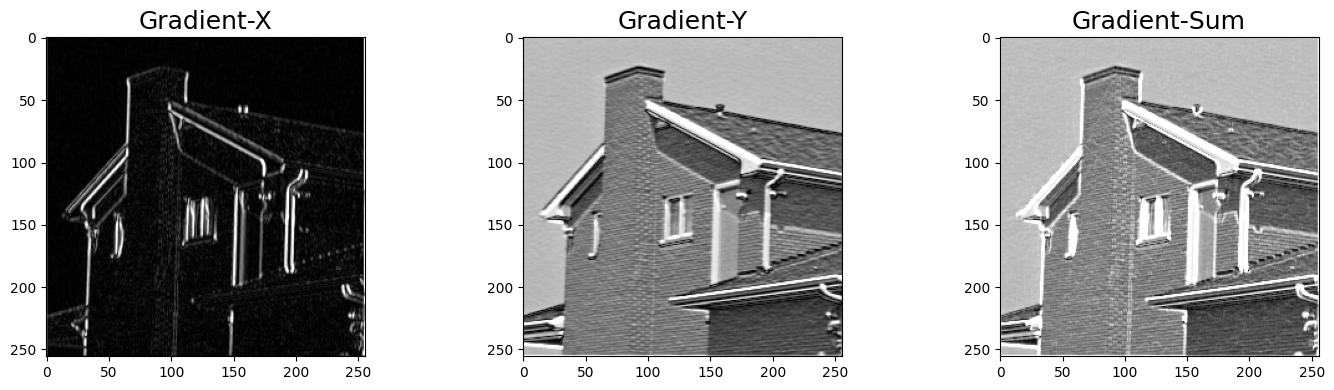

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(1 + 3*4.5,4))
img_gradient_x = conv2D(img_data, gradient_x)
img_gradient_y = conv2D(img_data, gradient_y)
display_axis(ax[0], np.abs(img_gradient_x), 'Gradient-X')
display_axis(ax[1], np.abs(img_gradient_y), 'Gradient-Y')
display_axis(ax[2], np.abs(img_gradient_x) + np.abs(img_gradient_y), 'Gradient-Sum')
fig.tight_layout()
fig.savefig('Data/Solutions/question_4_3.pdf', format='pdf', bbox_inches='tight')

## Question 5

In this question you will be completing a function `bilateral_filter(image, kernel, sigma_int, norm_fac)` which takes as input the `image`, a gaussian filter `kernel` which is the filter for the spatial dimension, `sigma_int` is the standard deviation of the gaussina along the intensity/pixel dimension and `norm_fac` is the normalization factor.

*Note:* For this filter you have two types of gaussian filters (one along the spatial dimension and the other along the pixel dimension). The gaussin filter along the spatial dimension can be obtained using the `gaussian_filter` function you wrote previously,however, the gaussian filter along the intensity dimension is a non-linear filter just like the median filter.

### **Answer 5.5:**
Copy paste your solution in the cell below on overleaf for Question 5.5.

In [ ]:
# Write your code in this cell.
def bilateral_filter(image: np.array, kernel: np.array = None, sigma_int: float = None, norm_fac: float = None):
  H, W = image.shape
  k = kernel.shape[0]
  pad = k // 2

  padded = np.zeros((H + 2*pad, W + 2*pad))
  padded[pad:pad+H, pad:pad+W] = image

  output = np.zeros_like(image)

  for i in range(H):
    for j in range(W):
      region = padded[i:i+k, j:j+k]

      center = padded[i+pad, j+pad]
      #intensity Gaussian
      intensity_weights = np.exp(-((region - center)**2) / (2 * sigma_int**2))
      weights = kernel * intensity_weights

      output[i, j] = np.sum(weights * region) / np.sum(weights)
  return output


In [ ]:
gauss_filt = gaussian_filter(11,3)
gauss_filt_img_data = conv2D(img_data, gauss_filt)
bilateral_filt_img_data = bilateral_filter(img_data, gauss_filt, sigma_int=0.2, norm_fac=0.0075) #These are some reference values, feel free to tune the values.

Comparison of bilateral filter with the gaussian filter, shows that the bilateral filter preserves the edges while smoothing the remaining image.

### **Answer 5.6:**

Execute the cell below and copy the saved image on overleaf for Question 5.6.

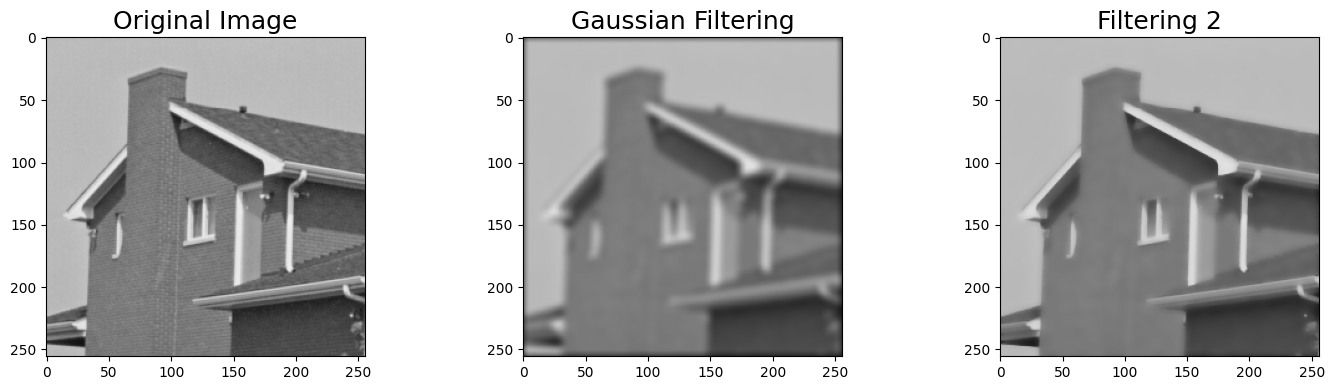

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(1 + 3*4.5,4))
display_axis(ax[0], img_data, 'Original Image')
display_axis(ax[1], gauss_filt_img_data, 'Gaussian Filtering')
display_axis(ax[2], bilateral_filt_img_data, 'Filtering 2')
fig.tight_layout()
fig.savefig('Data/Solutions/question_5_6.pdf', format='pdf', bbox_inches='tight')

---
# Part 2 — Blob & Corner Detection (EC ENGR 149, HW2)

# **PSET 2**

 These are some of the libraries/modules you will require for this homework.

In [ ]:
%matplotlib inline
import numpy as np
import scipy
from PIL import Image
import skimage
from skimage import data
from skimage.transform import warp, AffineTransform
import matplotlib.pyplot as plt
import copy
import os

These are some functions which will be useful throught the homework to (1) display a single grayscale image, (2) display multiple images using subplots.

In [ ]:
def display_gray(x: np.array, normalized:bool = False):
    plt.figure(figsize=(10,10))
    if not normalized:
        plt.imshow(x,cmap='gray',vmin=0,vmax=1)
    else:
        plt.imshow(x/x.max(),cmap='gray',vmin=0,vmax=1)

In [ ]:
def display_axis(ax: plt.axis, x: np.array, title: str, normalized:bool = False):
    if not normalized:
        ax.imshow(x,cmap='gray',vmin=0,vmax=1)
    else:
        ax.imshow(x/x.max(),cmap='gray',vmin=0,vmax=1)
    ax.set_title(title,size=18)

In [ ]:
def display_axis_bw(ax: plt.axis, x: np.array, title: str, normalized:bool = False, fig = None):
    if not normalized:
        imax = ax.imshow(x,cmap='gray',vmin=0,vmax=1)
    else:
        imax = ax.imshow(x/x.max(),cmap='gray',vmin=0,vmax=1)
    ax.set_title(title,size=18)
    fig.colorbar(imax,ax=ax)

In [ ]:
def display_axis_color(ax: plt.axis, x: np.array, title: str, normalized:bool = False, fig = None):
    if not normalized:
        imax = ax.imshow(x,cmap='coolwarm',vmin=0,vmax=1)
    else:
        imax = ax.imshow(x/x.max(),cmap='coolwarm',vmin=0,vmax=1)
    ax.set_title(title,size=18)
    fig.colorbar(imax,ax=ax)

# Question 2

### Blob Detection

In this question, you will be using the Laplacian of Gaussian Filter to perform blob detection. Using the previous parts of the question you should have an analytical expression for the Laplacian of Gaussian. You will be using that result to design a LoG filter. You will then be using that filter to detect blobs of different scales in the image by varying the standard deviation parameter.


In [ ]:
# Copy paste your conv2D function from the previous homework here.
# Write your answer in this cell. Then copy paste the code into the overleaf file corresponding to Question 2.
def conv2D(image: np.array, kernel: np.array = None):
    H, W = image.shape
    k = kernel.shape[0]
    pad = k // 2

    kernel = np.flip(kernel, (0, 1))

    padded = np.zeros((H + 2 * pad, W + 2 * pad), dtype=image.dtype)
    padded[pad:pad + H, pad:pad + W] = image

    output = np.zeros_like(image, dtype=np.float64)

    for i in range(H):
        for j in range(W):
            region = padded[i:i + k, j:j + k]
            output[i, j] = np.sum(region * kernel)

    return output

We use the two functions below to create blobs of different sizes. You will have 5 different sizes of blobs in the image below. You will have to tune the standard deviation of your LoG filter such that you get the maximum response.

In [ ]:
def make_circle(img: np.array, x: int, y: int, radius: int):
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if np.sqrt((x-i)**2 + (y-j)**2) < 1.0*radius:
                img[i,j]=1
    return img

In [ ]:
def draw_circle(img, y, radius):
    rad_buffer = radius + 5
    start = rad_buffer+5
    end = 255 - rad_buffer - 5
    centers = np.linspace(start, end, int((end-start)/(2*rad_buffer)))
    for c in centers:
        c = int(c)
        make_circle(img, y, c, radius)
    return img

In [ ]:
blob_img = np.zeros((256,256))
blob_img = draw_circle(blob_img, 25, 5)
blob_img = draw_circle(blob_img, 50, 10)
blob_img = draw_circle(blob_img, 85, 15)
blob_img = draw_circle(blob_img, 130, 20)
blob_img = draw_circle(blob_img, 200, 35)

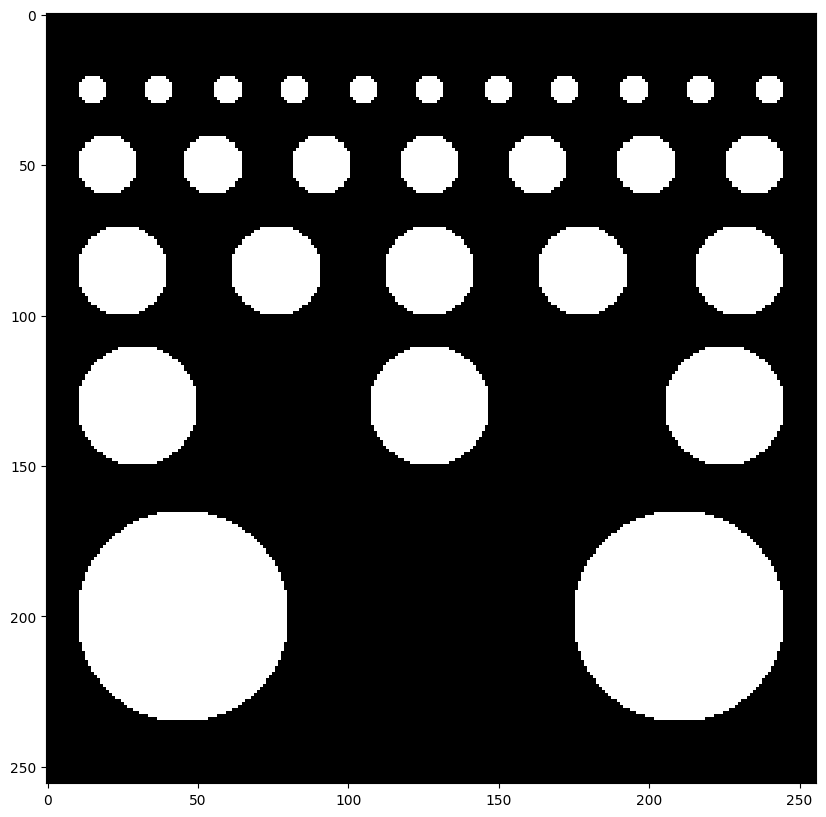

In [ ]:
display_gray(blob_img)

In [ ]:
img = copy.deepcopy(blob_img)

#### **Answer 2.5**

For this sub-part, you will be writing a function `log_filter(size, sigma)`, which takes as input the size of the LoG filter and the sigma, and returns a scale-normalized LoG filter.

Copy paste your solution in the cell below on Overleaf for Question 2.5.

In [ ]:
# Write your answer in this cell.
def log_filter(size: int, sigma: float):
    half = size // 2
    x, y = np.meshgrid(np.arange(-half, half + 1), np.arange(-half, half + 1))

    r2 = x**2 + y**2
    exponent = np.exp(-r2 / (2 * sigma**2))

    # Raw LoG (without normalization)
    raw_log = (1 / (2 * np.pi * sigma**4)) * (r2 / sigma**2 - 2) * exponent

    # Scale-normalized LoG (multiply by sigma^2)
    kernel = sigma**2 * raw_log

    return kernel

As you might have seen above, the image blobs have 5 different scales. Hence you have to find 5 `sigma` values which will give maximum response when the LoG filter is convolved with the image. You may want to use the results from the class lectures to find the values for `sigma`. To visualize maximum response we will be plotting the filtered images using a color map where blue color would correspond to smaller values and red color would correspond to higher values.

#### **Answer 2.6**

Tune the values of the 5 `sigmas`, so that you get the maximum response for each scale. So, `sigma_1` should be such that you get the maximum response for the smallest blobs, `sigma_5` should give you the maximum response for the largest blobs.

Write the values of the 5 `sigmas` you get here on Overleaf.

In [ ]:
sigma_1 = 2.5
sigma_2 = 4.0
sigma_3 = 6.0
sigma_4 = 9.0
sigma_5 = 14.0


log_1 = log_filter(21, sigma_1)
log_2 = log_filter(31, sigma_2)
log_3 = log_filter(41, sigma_3)
log_4 = log_filter(51, sigma_4)
log_5 = log_filter(81, sigma_5)

#### **Answer 2.7**

In this sub-part, you will visualize the LoG filters.

Upload the saved image on Overleaf for Question 2.7.

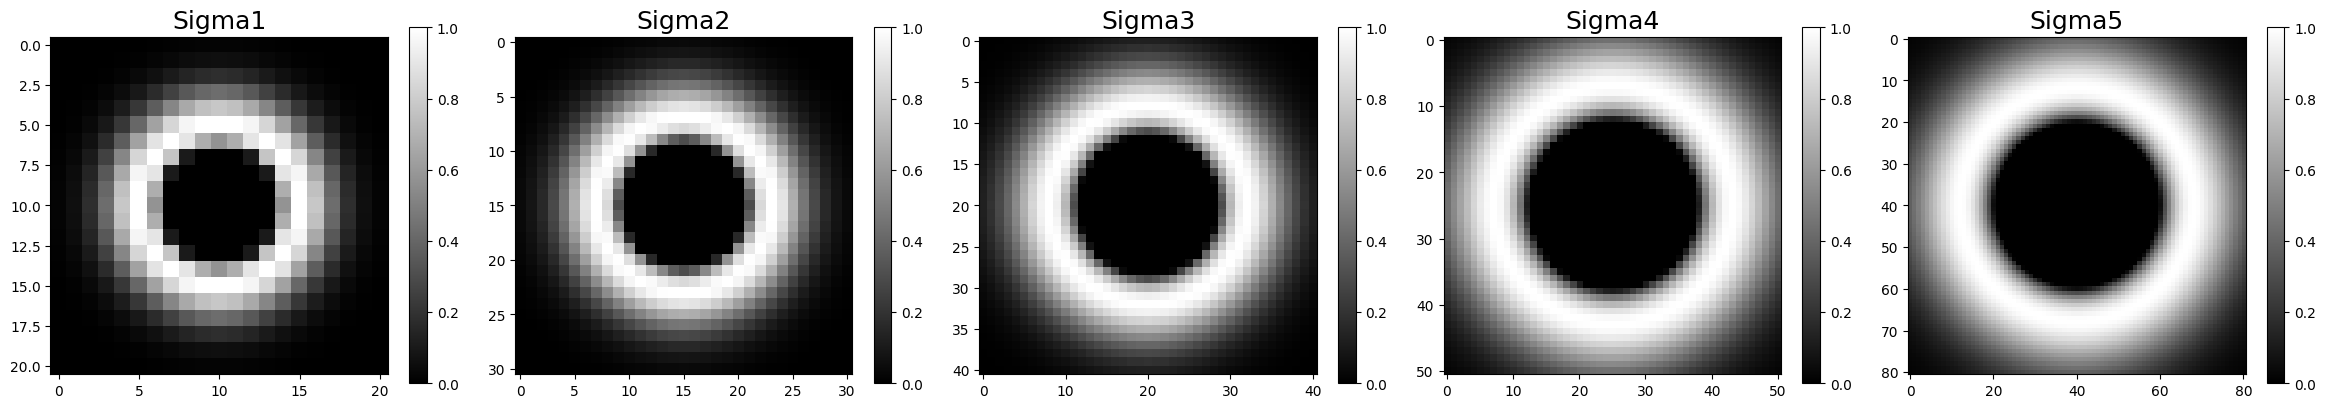

In [ ]:
fig, ax = plt.subplots(1,5,figsize=(1 + 5*4.5,4))
display_axis_bw(ax[0],log_1,'Sigma1',normalized=True,fig=fig)
display_axis_bw(ax[1],log_2,'Sigma2',normalized=True,fig=fig)
display_axis_bw(ax[2],log_3,'Sigma3',normalized=True,fig=fig)
display_axis_bw(ax[3],log_4,'Sigma4',normalized=True,fig=fig)
display_axis_bw(ax[4],log_5,'Sigma5',normalized=True,fig=fig)
fig.tight_layout()
os.makedirs('Data/Solutions', exist_ok=True)
fig.savefig('Data/Solutions/question_2_7.pdf', format='pdf', bbox_inches='tight')

Convolve the image with the 5 filters. Note that we multiply the filters with -1 so that the maximum response is positive.

In [ ]:
log_conv_1 = conv2D(img, -log_1)
log_conv_2 = conv2D(img, -log_2)
log_conv_3 = conv2D(img, -log_3)
log_conv_4 = conv2D(img, -log_4)
log_conv_5 = conv2D(img, -log_5)

#### **Answer 2.8**

In this sub-part, you will visualize the blob detection results. We also plot the colorbar with each image. You should use that to tune the values for `sigma`.

Upload the saved image on Overleaf for Question 2.8.

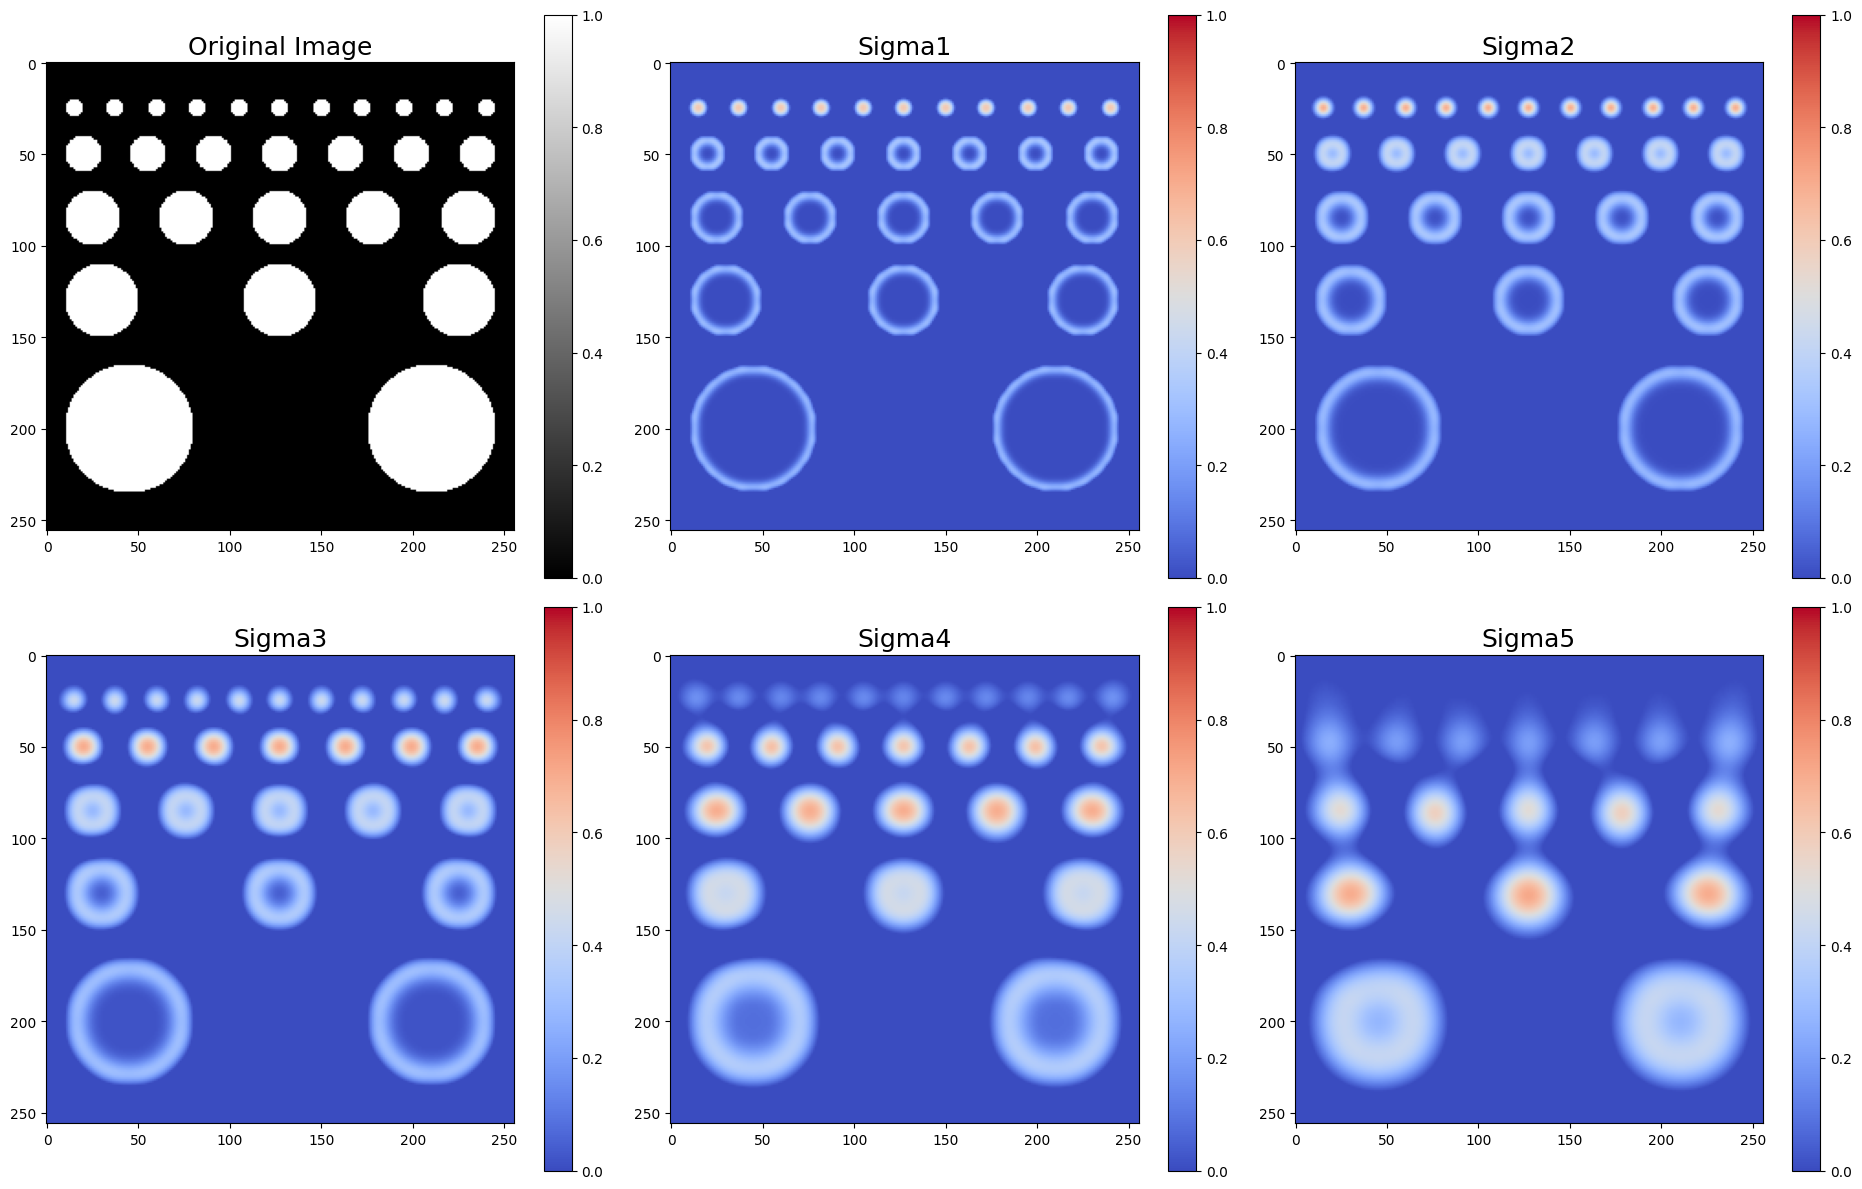

In [ ]:
fig, ax = plt.subplots(2,3,figsize=(1 + 3*6,2*6))
display_axis_bw(ax[0,0],img,'Original Image',fig=fig)
display_axis_color(ax[0,1],log_conv_1,'Sigma1',fig=fig)
display_axis_color(ax[0,2],log_conv_2,'Sigma2',fig=fig)
display_axis_color(ax[1,0],log_conv_3,'Sigma3',fig=fig)
display_axis_color(ax[1,1],log_conv_4,'Sigma4',fig=fig)
display_axis_color(ax[1,2],log_conv_5,'Sigma5',fig=fig)
fig.tight_layout()
fig.savefig('Data/Solutions/question_2_8.pdf', format='pdf', bbox_inches='tight')

# Question 3

## Corner Detection

In this question, you will be implementing the Harris corner detector. Corners serve as useful features in images for a variety of reasons: they are salient, well localized, and invariant to a variety of transformations (illumination, rotation, and scale changes). The Harris corner detector also possesses some of these invariances (rotation and intensity shift) but is not invariant to image and intensity scaling. Nevertheless, the Harris corner detector is still a popular method for detecting corners in images.


A grayscale test image (normalized to be in [0, 1]) containing some squares and a warped checkerboard is constructed below.

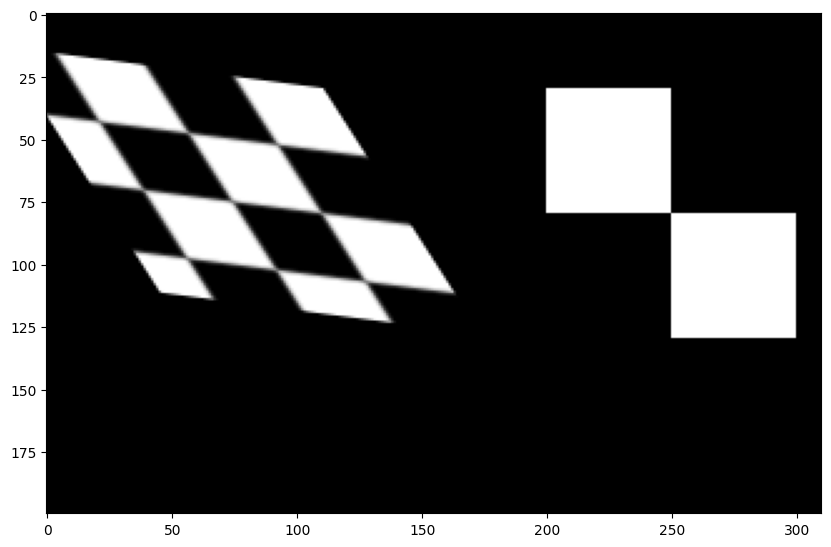

In [ ]:
# Sheared checkerboard
tform = AffineTransform(scale=(1.3, 1.1), rotation=1, shear=0.7,
                        translation=(110, 30))
image = warp(data.checkerboard()[:90, :90], tform.inverse,
             output_shape=(200, 310))

# Two squares
image[30:80, 200:250] = 1
image[80:130, 250:300] = 1

display_gray(image)

### Computing Image Gradients

The first step in the Harris corner detector is to compute the image gradients. While there are a variety of different methods to compute gradients, you will use the Sobel filter, which is defined below for the x and y directions.

In [ ]:
sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

After defining the Sobel filters, you need to apply them to obtain the gradients. Complete a function ```compute_image_gradient(image)``` that returns the horizontal (along the x direction) and vertical (along the y direction) image gradients using the provided Sobel filters. For this function (and all convolutions that follow), use the ```conv2D(image, kernel)``` function, which you should copy paste into the cell at the beginning of Question 2.

#### **Answer 3.1**

Copy paste your solution in the cell below on Overleaf for Question 3.1.

In [ ]:
# Write your code in this cell.

def compute_image_gradient(image: np.array):

    sobel_x = np.array([[1, 0, -1],
                        [2, 0, -2],
                        [1, 0, -1]])

    sobel_y = np.array([[1, 2, 1],
                        [0, 0, 0],
                        [-1, -2, -1]])

    gradient_x = conv2D(image, sobel_x)
    gradient_y = conv2D(image, sobel_y)

    return gradient_x, gradient_y

Display the absolute gradient along the horizontal and vertical directions and their sum. You should observe that the gradient in the horizontal (x-direction) is unable to capture the horizontal edges while the gradient in the vertical (y-direction) is unable to capture the vertical edges. Both gradients capture the diagonal edges, but they may appear dimmer than the horizontal and vertical edges.

#### **Answer 3.2**

Execute the cell below and copy the saved image on Overleaf for Question 3.2.

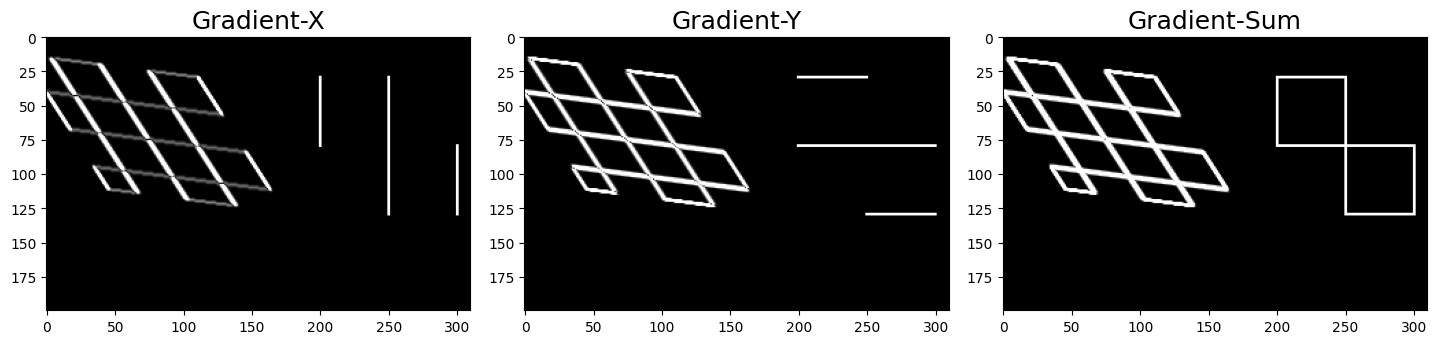

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(1 + 3*4.5,4))
img_gradient_x, img_gradient_y = compute_image_gradient(image)
display_axis(ax[0], np.abs(img_gradient_x), 'Gradient-X')
display_axis(ax[1], np.abs(img_gradient_y), 'Gradient-Y')
display_axis(ax[2], np.abs(img_gradient_x) + np.abs(img_gradient_y), 'Gradient-Sum')
fig.tight_layout()
os.makedirs('Data/Solutions', exist_ok=True)
fig.savefig('Data/Solutions/question_3_2.pdf', format='pdf', bbox_inches='tight')

### **Computing the Covariance Matrix**

After computing the gradients, the Harris corner detector then computes the covariance matrix of the gradients (see lecture 5 slide 26). Complete the function ```grad_covariance(image, size)``` that computes each pixel's covariance matrix using the ```size x size``` window centered at the pixel. This function should return three matrices $I_{xx}, I_{xy}, I_{yy}$ containing the top-left, diagonal, and bottom-right terms, respectively, of every pixel's covariance matrix. When computing the covariance, you do not need to subtract the means of the image gradients. The average filter is provided below as a useful function.

In [ ]:
# This is the standard box filter which computes the mean of all the pixels inside the filter.
def average_filter(size: int):
    assert size%2 == 1
    return 1.0 * np.ones((size,size))/(size**2)

#### **Answer 3.3**

Copy paste your solution in the cell below on Overleaf for Question 3.3.

In [ ]:
# Write your code in this cell.

def grad_covariance(image: np.array, size: int):

    gradient_x, gradient_y = compute_image_gradient(image)

    I_xx = gradient_x * gradient_x
    I_xy = gradient_x * gradient_y
    I_yy = gradient_y * gradient_y

    avg = average_filter(size)

    I_xx = conv2D(I_xx, avg)
    I_xy = conv2D(I_xy, avg)
    I_yy = conv2D(I_yy, avg)

    return I_xx, I_xy, I_yy

### **Harris Response Function**

Finally, the Harris corner detector uses the covariance matrix to compute a response function, which is then thresholded to obtain the locations of the corners. Complete the function ```harris_response(image, k, size)``` which computes the Harris response function (see lecture 5 slide 43, Harris & Stephens (1988)) for an image using a ```size x size``` window around every pixel. The parameter ```k``` corresponds to the parameter in the Harris response function.

#### **Answer 3.4**

Copy paste your solution in the cell below on Overleaf for Question 3.4.

In [ ]:
# Write your code in this cell.

def harris_response(image: np.array, k: float, size: int):

    I_xx, I_xy, I_yy = grad_covariance(image, size)

    det_M = I_xx * I_yy - I_xy**2

    trace_M = I_xx + I_yy

    response = det_M - k * (trace_M**2)

    return response

#### **Answer 3.5**

Execute the cell below and copy the saved image on Overleaf for Question 3.5. The cell below finds every pixel location where the Harris response function is above a certain threshold and then shows the locations of these pixels (the corner detections) in cyan.

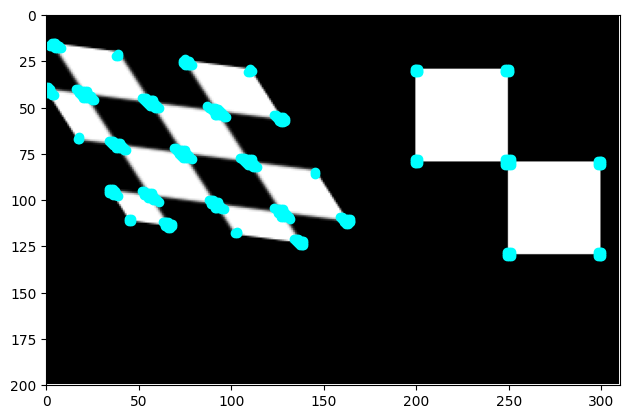

In [ ]:
coords = np.argwhere(harris_response(image, 0.05, 3) > 0.02)
fig, ax = plt.subplots()
ax.imshow(image, cmap=plt.cm.gray)
ax.plot(coords[:, 1], coords[:, 0], color='cyan', marker='o',
        linestyle='None', markersize=6)
ax.axis((0, 310, 200, 0))
fig.tight_layout()
plt.show()
fig.savefig('Data/Solutions/question_3_5.pdf', format='pdf', bbox_inches='tight')

### **Non-Maximum Suppression**

You should observe from the above image that all corners are detected. However, some corners are detected multiple times, which is due to simply thresholding the Harris response. To suppress multiple detections, you will implement, in steps, a function ```non_max_suppression(harris_response, distance, threshold)``` that applies non-maximum suppression to the Harris corner response and returns the remaining corner detections.

Non-maximum suppression works as follows:
1. Threshold the Harris response map to obtain the pixel locations where the response is greater than a certain threshold. These pixel locations form our candidate corner detections.
2. Sort these detections based on maximum response value.
3. Go through the sorted detections in order and for each detection, remove other detections that are within a certain Euclidean distance from the current detection. This step suppresses detections that are not local maxima.

You will implement the three steps of non-maximum suppression in order. First, complete the function ```threshold_harris_response(harris_response, threshold)```, which returns the indices of the Harris response map corresponding to values that are greater than some threshold.

#### **Answer 3.6**

Copy paste your solution in the cell below on Overleaf for Question 3.6.

In [ ]:
# Write your code in this cell.

def threshold_harris_response(harris_response: np.array, threshold: float):

    indices = np.argwhere(harris_response > threshold)

    return indices

Then, complete the function ```sort_detections(candidate_detections, harris_response)```, which returns the candidate detections sorted based on maximum Harris response value.

#### **Answer 3.7**

Copy paste your solution in the cell below on Overleaf for Question 3.7.


In [ ]:
# Write your code in this cell.

def sort_detections(candidate_detections: np.array, harris_response: np.array):

    responses = harris_response[
        candidate_detections[:, 0],
        candidate_detections[:, 1]
    ]

    sorted_indices = np.argsort(responses)[::-1]

    sorted_detections = candidate_detections[sorted_indices]

    return sorted_detections

The final step is to go through the sorted detections and suppress detections that are not local maxima. Complete the function ```local_max(sorted_detections, distance)```, which goes through the sorted detections and returns only the detections that are local maxima (using local neighborhoods defined by a Euclidean distance threshold ```distance```).

A function that computes Euclidean distance between two points is provided below for convenience.

In [ ]:
def l2_distance(p1: np.array, p2: np.array):
    return np.linalg.norm(p1 - p2, ord=2)

#### **Answer 3.8**

Copy paste your solution in the cell below on Overleaf for Question 3.8.


In [ ]:
# Write your code in this cell.


def local_max(sorted_detections: np.array, distance: float):

    selected = []

    for detection in sorted_detections:

        keep = True

        for corner in selected:

            dist = np.linalg.norm(detection - corner)

            if dist < distance:
                keep = False
                break

        if keep:
            selected.append(detection)

    return np.array(selected)

Now, combine the three previously implemented functions to complete the function ```non_max_suppression(harris_response, distance, threshold)```, which applies non-maximum suppression to the Harris corner response and returns the remaining corner detections as a NumPy array of (row, col) locations.

#### **Answer 3.9**

Copy paste your solution in the cell below on Overleaf for Question 3.9.

In [ ]:
# Write your code in this cell.

def non_max_suppression(harris_response: np.array,
                        distance: float,
                        threshold: float):

    candidate_detections = threshold_harris_response(
        harris_response,
        threshold
    )

    sorted_detections = sort_detections(
        candidate_detections,
        harris_response
    )

    final_detections = local_max(
        sorted_detections,
        distance
    )

    return final_detections

#### **Answer 3.10**

Execute the cell below and copy the saved image on Overleaf for Question 3.10. The cell below runs non-maximum suppression on the Harris response map and then shows the locations of the corner detections in cyan. Duplicate corner detections should now be removed.

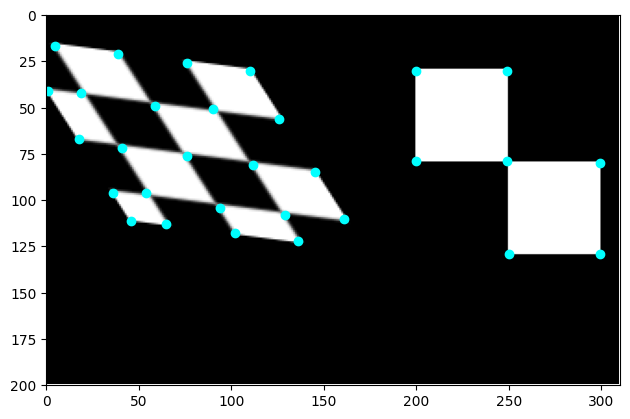

In [ ]:
coords = non_max_suppression(harris_response(image, 0.05, 3), 10.0, 0.02)
fig, ax = plt.subplots()
ax.imshow(image, cmap=plt.cm.gray)
ax.plot(coords[:, 1], coords[:, 0], color='cyan', marker='o',
        linestyle='None', markersize=6)
ax.axis((0, 310, 200, 0))
fig.tight_layout()
plt.show()
fig.savefig('Data/Solutions/question_3_10.pdf', format='pdf', bbox_inches='tight')